# Построение модели для определения региона, где добыча нефти принесёт наибольшую прибыль добывающей компании «ГлавРосГосНефть»

**Формирование задачи**

В рамках проекта необходимо принять решение о местоположении новой скважины добывающей компании «ГлавРосГосНефть». Проект предусматривает построение модели для определения региона, где добыча принесёт наибольшую прибыль и анализ возможной прибыли и рисков техникой Bootstrap.

Шаги для выбора локации:

- Сбор характеристик для скважин в избранном регионе: качество нефти и объём её запасов;
- Построение модели для предсказания объёма запасов в новых скважинах;
- Выбор скважины с самыми высокими оценками значений;
- Определение региона с максимальной суммарной прибылью отобранных скважин.

**План исследования**

- Загрузка и предобработка данных
- Исследовательский анализ данных
- Корреляционный анализ
- Обучение и проверка модели для каждого региона:
    - Разбивка данных на обучающую и валидационную выборки в соотношении 75:25
    - Обучение модели и предсказания на валидационной выборке
    - Сохранение предсказания и правильных ответов на валидационной выборке
    - Печать на экране средний запас предсказанного сырья и RMSE модели
    - Анализ результатов
- Подготовка к расчёту прибыли:
    - Сохранение всех ключевых значений для расчётов в отдельных переменных
    - Рассчет достаточного объёма сырья для безубыточной разработки новой скважины
    - Сравнение полученного объёма сырья со средним запасом в каждом регионе
    - Выводы по этапу подготовки расчёта прибыли
- Вывод функции для расчёта прибыли по выбранным скважинам и предсказаниям модели:
    - Выбор скважины с максимальными значениями предсказаний
    - Суммирование целевого значения объёма сырья, соответствующее этим предсказаниям
    - Расчет прибыли для полученного объёма сырья
- Расчет рисков и прибыли для каждого региона:
    - Применение техники Bootstrap с 1000 выборок, чтобы найти распределение прибыли
    - Расчет средней прибыли, 95%-ого доверительного интервала и риска убытков
    - Вывод о регионе для разработки скважин и обоснование выбора

**Описание данных***

Данные геологоразведки трёх регионов находятся в файлах: 

- /datasets/geo_data_0.csv
- /datasets/geo_data_1.csv
- /datasets/geo_data_2.csv

| Показатель     | Описание                                  |
|----------------|-------------------------------------------|
| **id**         | уникальный идентификатор скважины         |
| **f0, f1, f2** |  три признака точек                       |
| **product**    | объём запасов в скважине (тыс. баррелей)  |

**Условия задачи***

- Для обучения модели подходит только линейная регрессия (остальные — недостаточно предсказуемые).
- При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки.
- Бюджет на разработку скважин в регионе — 10 млрд рублей.
- При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей.
- После оценки рисков необходимо оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.

<i>*Данные синтетические: детали контрактов и характеристики месторождений не разглашаются.</i>

## Загрузка и предобработка данных

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
!pip install phik -q
import phik 
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
RANDOM_STATE = 42
state = np.random.RandomState(12345)

In [2]:
#считаем csv - файл с данными `geo_data_0.csv`
try:
    geo_data_0 = pd.read_csv('geo_data_0.csv')
except:
    geo_data_0 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_0.csv')

#считаем csv - файл с данными `geo_data_1.csv`
try:
    geo_data_1 = pd.read_csv('geo_data_1.csv')
except:
    geo_data_1 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_1.csv')
    
#считаем csv - файл с данными `geo_data_2.csv`
try:
    geo_data_2 = pd.read_csv('geo_data_2.csv')
except:
    geo_data_2 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_2.csv')

### Предобработка данных для датасета 'geo_data_0'

In [3]:
def desc_data(data): #создадим функцию для описания датасетов
    display(data.head(10)) 
    list_c = data.columns
    print(data.info())
    print('-'* 25)
    print('Количество полных дубликатов ', data.duplicated().sum())
    for col_l in list_c:
        print('-'* 25)
        print(col_l,': кол-во NaN',data[col_l].isna().sum(),\
              ', процент NaN', round(data[col_l].isna().mean()*100,2),'%')
        print(data[col_l].describe())

In [4]:
desc_data(geo_data_0)

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647
5,wX4Hy,0.969570,0.489775,-0.735383,64.741541
6,tL6pL,0.645075,0.530656,1.780266,49.055285
7,BYPU6,-0.400648,0.808337,-5.624670,72.943292
8,j9Oui,0.643105,-0.551583,2.372141,113.356160
9,OLuZU,2.173381,0.563698,9.441852,127.910945


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count     100000
unique     99990
top        74z30
freq           2
Name: id, dtype: object
-------------------------
f0 : кол-во NaN 0 , процент NaN 0.0 %
count    100000.000000
mean          0.500419
std           0.871832
min          -1.408605
25%          -0.072580
50%           0.502360
75%           1.073581
max           2.362331
Name: f0, dtype: float64
-------------------------
f1 : кол-во NaN 0 , процент NaN 0.0 %
count    1

| Показатель  | Описание                                 | Формат  | Примечание               |
|-------------|------------------------------------------|---------|--------------------------|
| **id**      | уникальный идентификатор скважины        | object  | формат данных оптимален  |
| **f0**      | признак точки №1                         | float64 | формат данных оптимален  |
| **f1**      | признак точки №2                         | float64 | формат данных оптимален  |
| **f2**      | признак точки №3                         | float64 | формат данных оптимален  |
| **product** | объём запасов в скважине (тыс. баррелей) | float64 | формат данных оптимален  |

In [5]:
geo_data_0.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


Данные показали, что отсутствуют полные дубликаты, но уникальных значений по id меньше, чем количество данных.

In [6]:
def table(data):
    table = data.pivot_table(index='id', values='product', aggfunc='count').reset_index()
    table.columns = ['id','Количество']
    table = table.sort_values('Количество',ascending=False)
    table_only_2 = table.query('Количество==2')
    list = table_only_2['id'].unique()
    display(data.query('id in @list').sort_values('id',ascending=False))

In [7]:
table(geo_data_0)

,id,f0,f1,f2,product
90815,fiKDv,0.049883,0.841313,6.394613,137.346586
16633,fiKDv,0.157341,1.028359,5.585586,95.817889
41724,bxg6G,-0.823752,0.546319,3.630479,93.007798
1364,bxg6G,0.411645,0.856830,-3.653440,73.604260
97785,bsk9y,0.378429,0.005837,0.160827,160.637302
89582,bsk9y,0.398908,-0.400253,10.122376,163.433078
92341,TtcGQ,0.110711,1.022689,0.911381,101.318008
60140,TtcGQ,0.569276,-0.104876,6.440215,85.350186
21426,Tdehs,0.829407,0.298807,-0.049563,96.035308
75715,Tdehs,0.112079,0.430296,3.218993,60.964018


### Предобработка данных для датасета 'geo_data_1'

In [8]:
desc_data(geo_data_1)

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305
5,HHckp,-3.327590,-2.205276,3.003647,84.038886
6,h5Ujo,-11.142655,-10.133399,4.002382,110.992147
7,muH9x,4.234715,-0.001354,2.004588,53.906522
8,YiRkx,13.355129,-0.332068,4.998647,134.766305
9,jG6Gi,1.069227,-11.025667,4.997844,137.945408


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count     100000
unique     99996
top        5ltQ6
freq           2
Name: id, dtype: object
-------------------------
f0 : кол-во NaN 0 , процент NaN 0.0 %
count    100000.000000
mean          1.141296
std           8.965932
min         -31.609576
25%          -6.298551
50%           1.153055
75%           8.621015
max          29.421755
Name: f0, dtype: float64
-------------------------
f1 : кол-во NaN 0 , процент NaN 0.0 %
count    1

| Показатель  | Описание                                 | Формат  | Примечание               |
|-------------|------------------------------------------|---------|--------------------------|
| **id**      | уникальный идентификатор скважины        | object  | формат данных оптимален  |
| **f0**      | признак точки №1                         | float64 | формат данных оптимален  |
| **f1**      | признак точки №2                         | float64 | формат данных оптимален  |
| **f2**      | признак точки №3                         | float64 | формат данных оптимален  |
| **product** | объём запасов в скважине (тыс. баррелей) | float64 | формат данных оптимален  |

In [9]:
geo_data_1.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


In [10]:
table(geo_data_1)

,id,f0,f1,f2,product
47591,wt4Uk,-9.091098,-8.109279,-0.002314,3.179103
82873,wt4Uk,10.259972,-9.376355,4.994297,134.766305
2721,bfPNe,-9.494442,-5.463692,4.006042,110.992147
82178,bfPNe,-6.202799,-4.820045,2.995107,84.038886
1305,LHZR0,11.170835,-1.945066,3.002872,80.859783
41906,LHZR0,-8.989672,-4.286607,2.009139,57.085625
5849,5ltQ6,-3.435401,-12.296043,1.999796,57.085625
84461,5ltQ6,18.213839,2.191999,3.993869,107.813044


### Предобработка данных для датасета 'geo_data_2'

In [11]:
desc_data(geo_data_2)

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746
5,LzZXx,-0.758092,0.710691,2.585887,90.222465
6,WBHRv,-0.574891,0.317727,1.773745,45.641478
7,XO8fn,-1.906649,-2.458350,-0.177097,72.480640
8,ybmQ5,1.776292,-0.279356,3.004156,106.616832
9,OilcN,-1.214452,-0.439314,5.922514,52.954532


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count     100000
unique     99996
top        xCHr8
freq           2
Name: id, dtype: object
-------------------------
f0 : кол-во NaN 0 , процент NaN 0.0 %
count    100000.000000
mean          0.002023
std           1.732045
min          -8.760004
25%          -1.162288
50%           0.009424
75%           1.158535
max           7.238262
Name: f0, dtype: float64
-------------------------
f1 : кол-во NaN 0 , процент NaN 0.0 %
count    1

| Показатель  | Описание                                 | Формат  | Примечание               |
|-------------|------------------------------------------|---------|--------------------------|
| **id**      | уникальный идентификатор скважины        | object  | формат данных оптимален  |
| **f0**      | признак точки №1                         | float64 | формат данных оптимален  |
| **f1**      | признак точки №2                         | float64 | формат данных оптимален  |
| **f2**      | признак точки №3                         | float64 | формат данных оптимален  |
| **product** | объём запасов в скважине (тыс. баррелей) | float64 | формат данных оптимален  |

In [12]:
geo_data_2.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


In [13]:
table(geo_data_2)

,id,f0,f1,f2,product
28039,xCHr8,1.633027,0.368135,-2.378367,6.120525
43233,xCHr8,-0.847066,2.101796,5.597130,184.388641
44378,Vcm5J,-1.229484,-2.439204,1.222909,137.968290
95090,Vcm5J,2.587702,1.986875,2.482245,92.327572
11449,VF7Jo,2.122656,-0.858275,5.746001,181.716817
49564,VF7Jo,-0.883115,0.560537,0.723601,136.233420
45404,KUPhW,0.231846,-1.698941,4.990775,11.716299
55967,KUPhW,1.211150,3.176408,5.543540,132.831802


**<div style="border:solid green 2px; padding: 20px">
Вывод: На первом этапе были выгружены и изучены данные трех датасетов. Данные, представленнные в таблицах, соответствуют изначально поставленной задаче. Полных дубликатов нет. Формат данных оптимален. Отмечено наличие дублирования id, но данные признаков и объемов запасов разные. Есть предположение, что это либо техническая ошибка, либо по каким-то причинам под одним id числяться две скважины (возможно, близкое расположение).**

## Исследовательский анализ данных

Несмотря на то, что характер признаков неизвестен, проведем полноценный исследовательский анализ.

### Исследовательский анализ данных для датасета 'geo_data_0'

In [14]:
geo_data_0.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


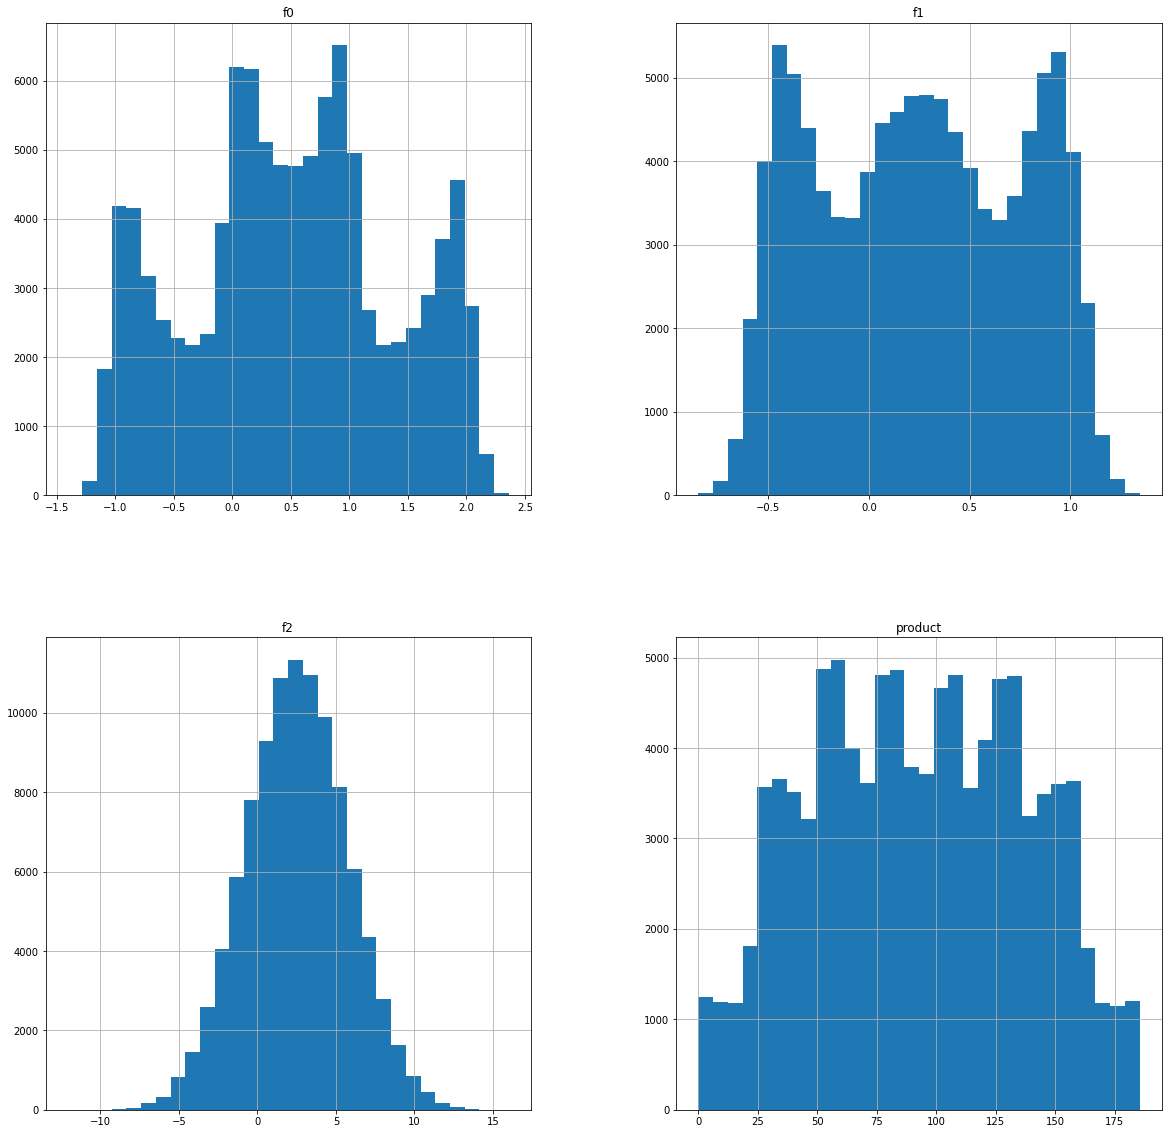

In [15]:
geo_data_0.drop('id', axis=1).hist(figsize=(20, 20),bins=30);

Выбросов не наблюдается.

Проанализируем количественные признаки.

In [16]:
def hist_plot(data,index,bins):
    plt.figure(figsize=(20, 5))
    plt.suptitle('Гистограмма и диаграмма размаха для показателя "' + index+'"', fontsize=20, y=1.05)
        
    
    plt.subplot(1, 2, 1)
    mean = np.mean(data[index])
    median = np.median(data[index])
    sns.histplot(data[index], bins=bins, kde=True, color='skyblue')
    plt.axvline(mean, color='r', linestyle='dashed', linewidth=1, label=f'Среднее: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='dashed', linewidth=1, label=f'Медиана: {median:.2f}');
    plt.ylabel('Количество показателей')
    plt.title('Гистограмма по значению ' + index, fontsize=16)
    plt.legend()
    plt.xlabel(index);
    
    plt.subplot(1, 2, 2)
    ax = sns.boxplot(y=index, data=data)
    plt.title('Boxplot для показателя ' + index, fontsize=16)
    plt.axhline(y=mean, color='g', linestyle='--')
    plt.ylabel(index, fontsize=14);
    plt.show()

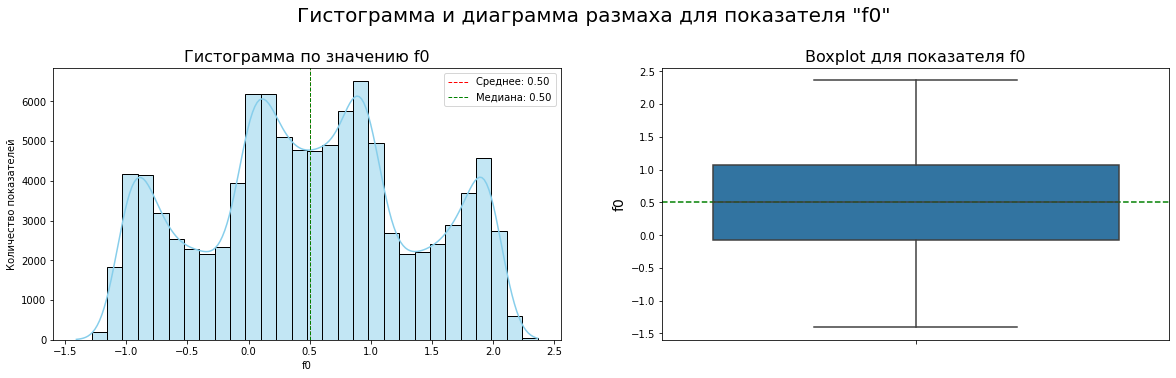

In [17]:
hist_plot(geo_data_0,'f0',30)

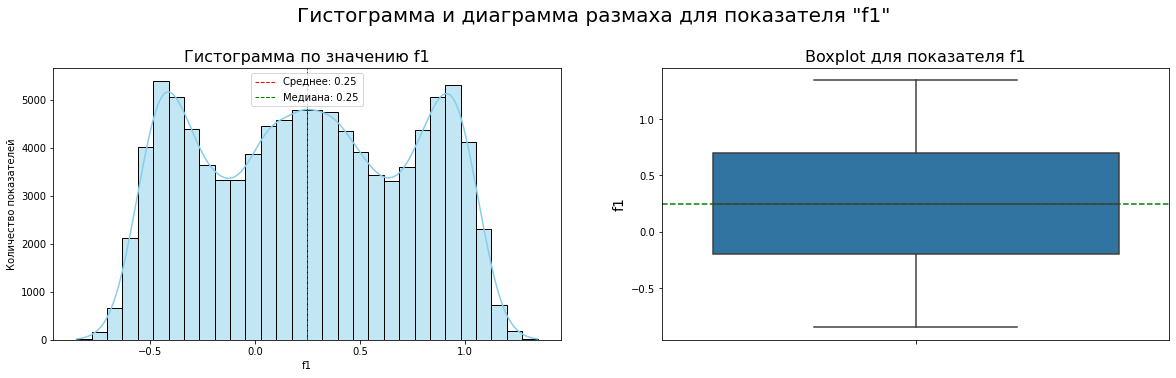

In [18]:
hist_plot(geo_data_0,'f1',30)

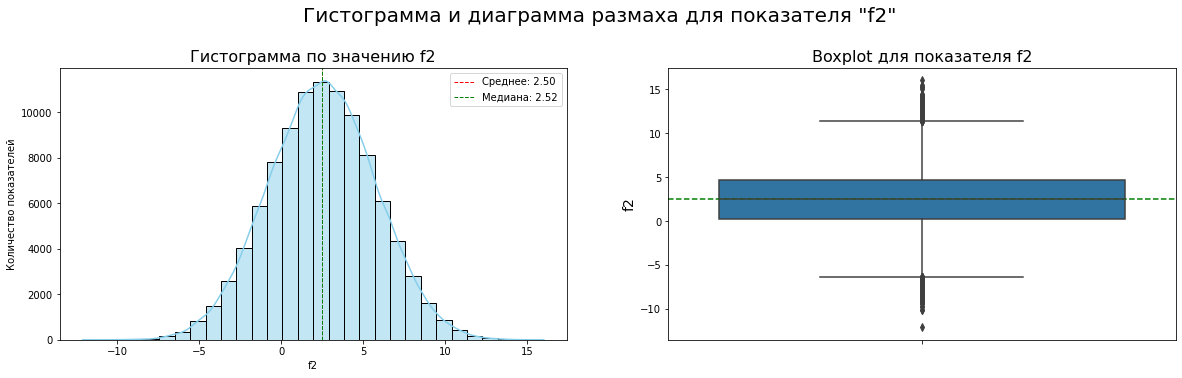

In [19]:
hist_plot(geo_data_0,'f2',30)

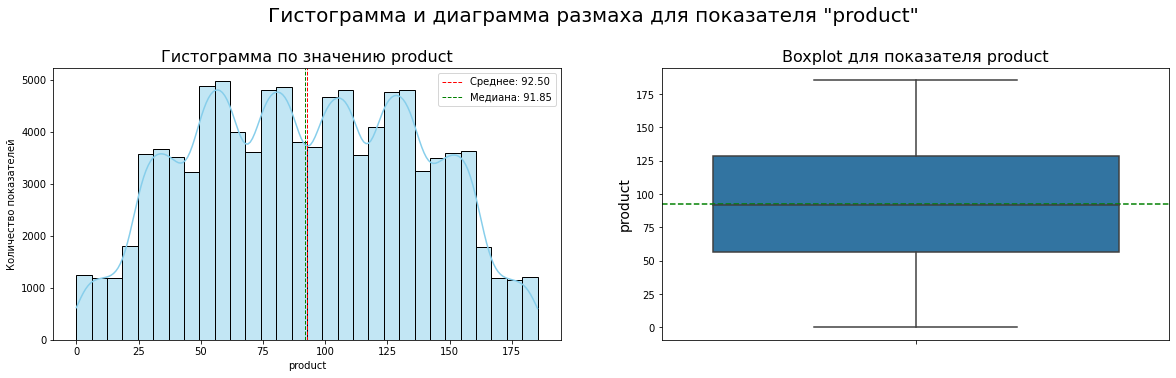

In [20]:
hist_plot(geo_data_0,'product',30)

### Исследовательский анализ данных для датасета 'geo_data_1'

In [21]:
geo_data_1.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


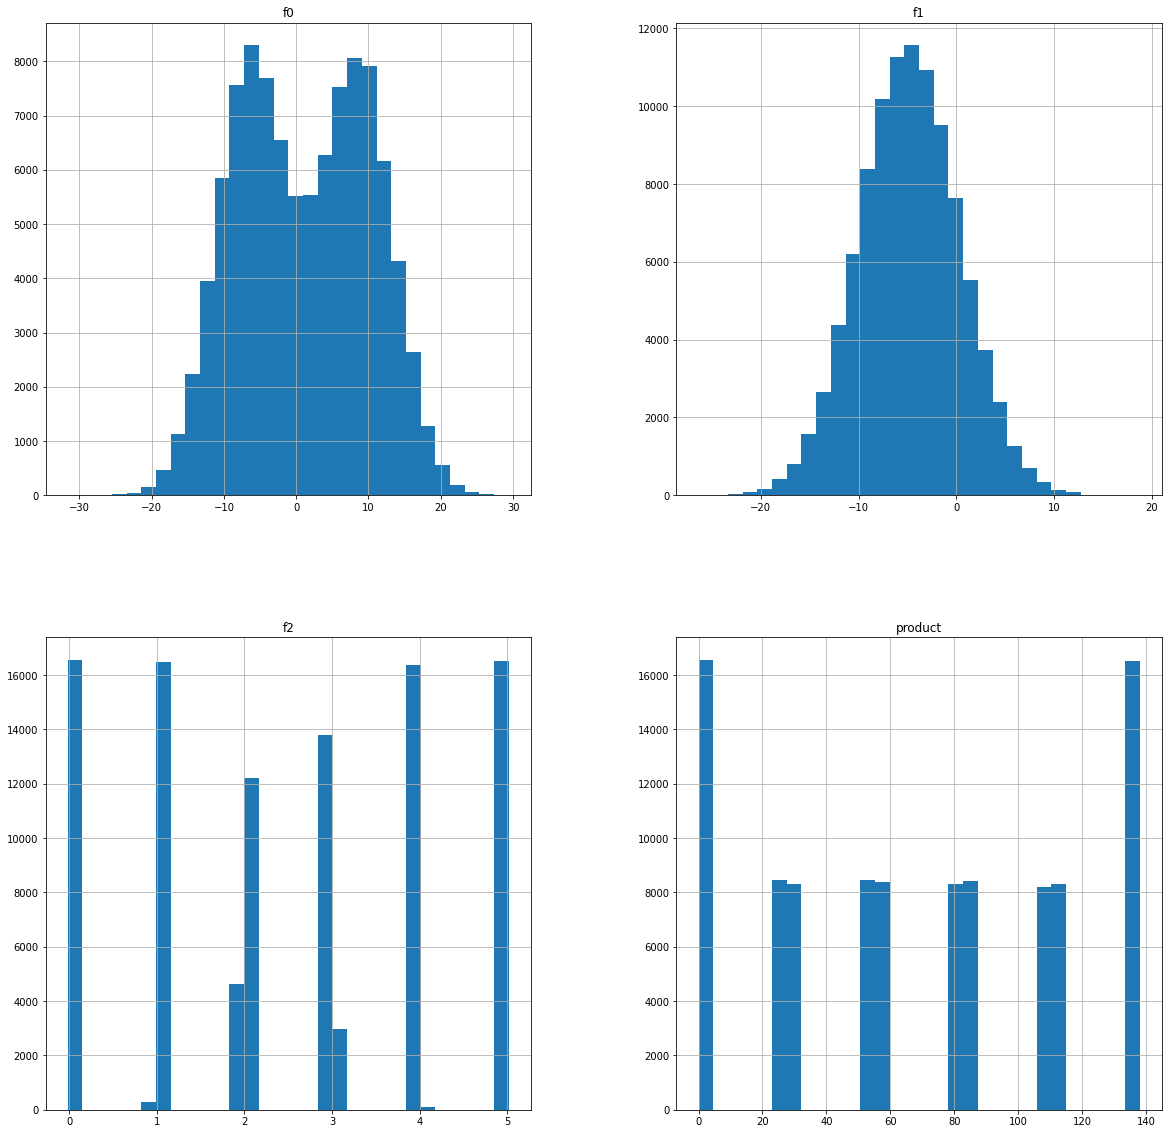

In [22]:
geo_data_1.drop('id', axis=1).hist(figsize=(20, 20),bins=30);

Выбросов не наблюдается.

Проанализируем количественные признаки.

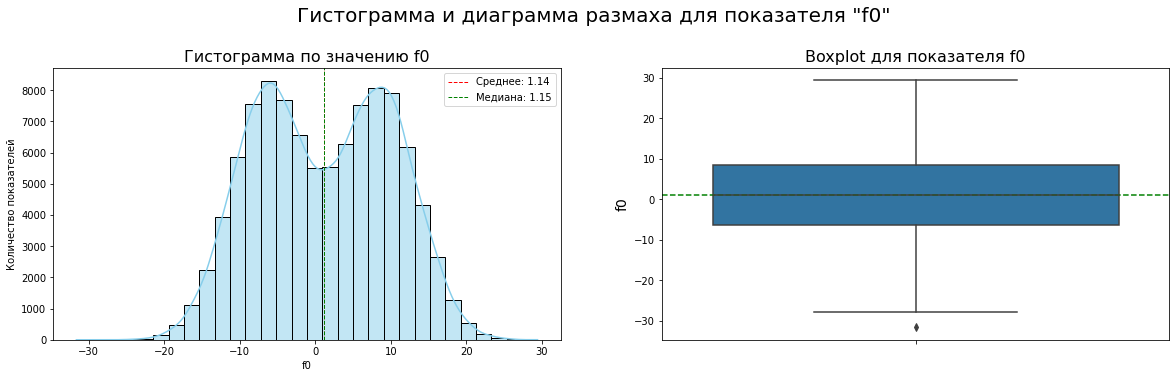

In [23]:
hist_plot(geo_data_1,'f0',30)

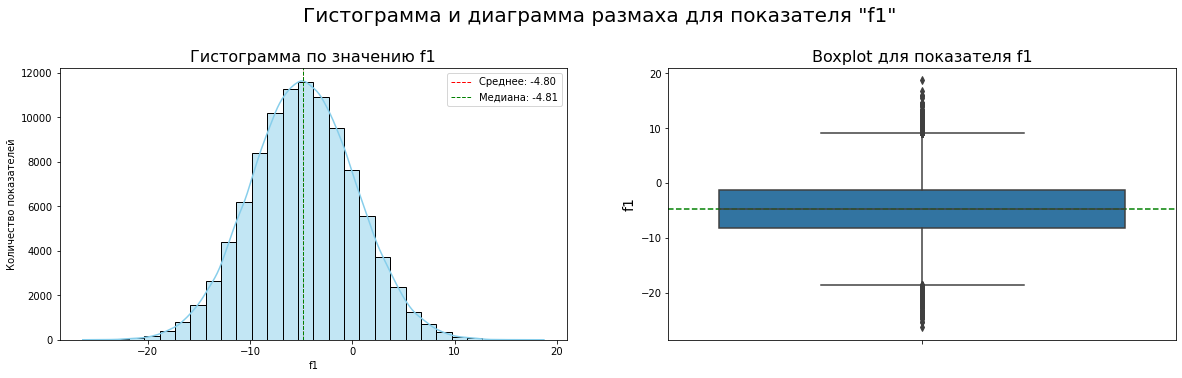

In [24]:
hist_plot(geo_data_1,'f1',30)

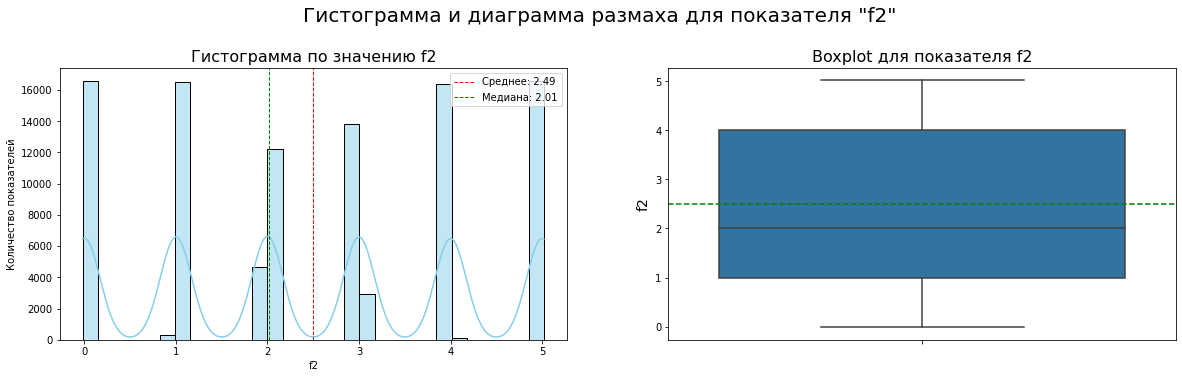

In [25]:
hist_plot(geo_data_1,'f2',30)

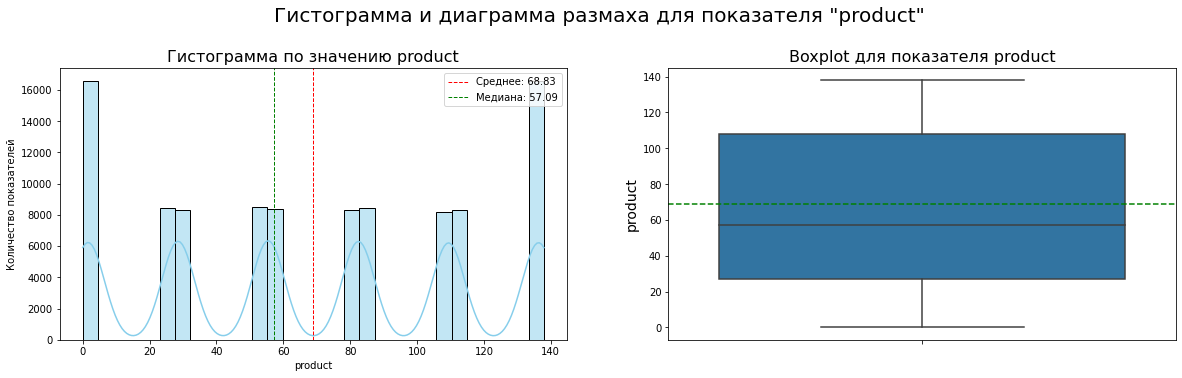

In [26]:
hist_plot(geo_data_1,'product',30)

### Исследовательский анализ данных для датасета 'geo_data_2'

In [27]:
geo_data_2.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


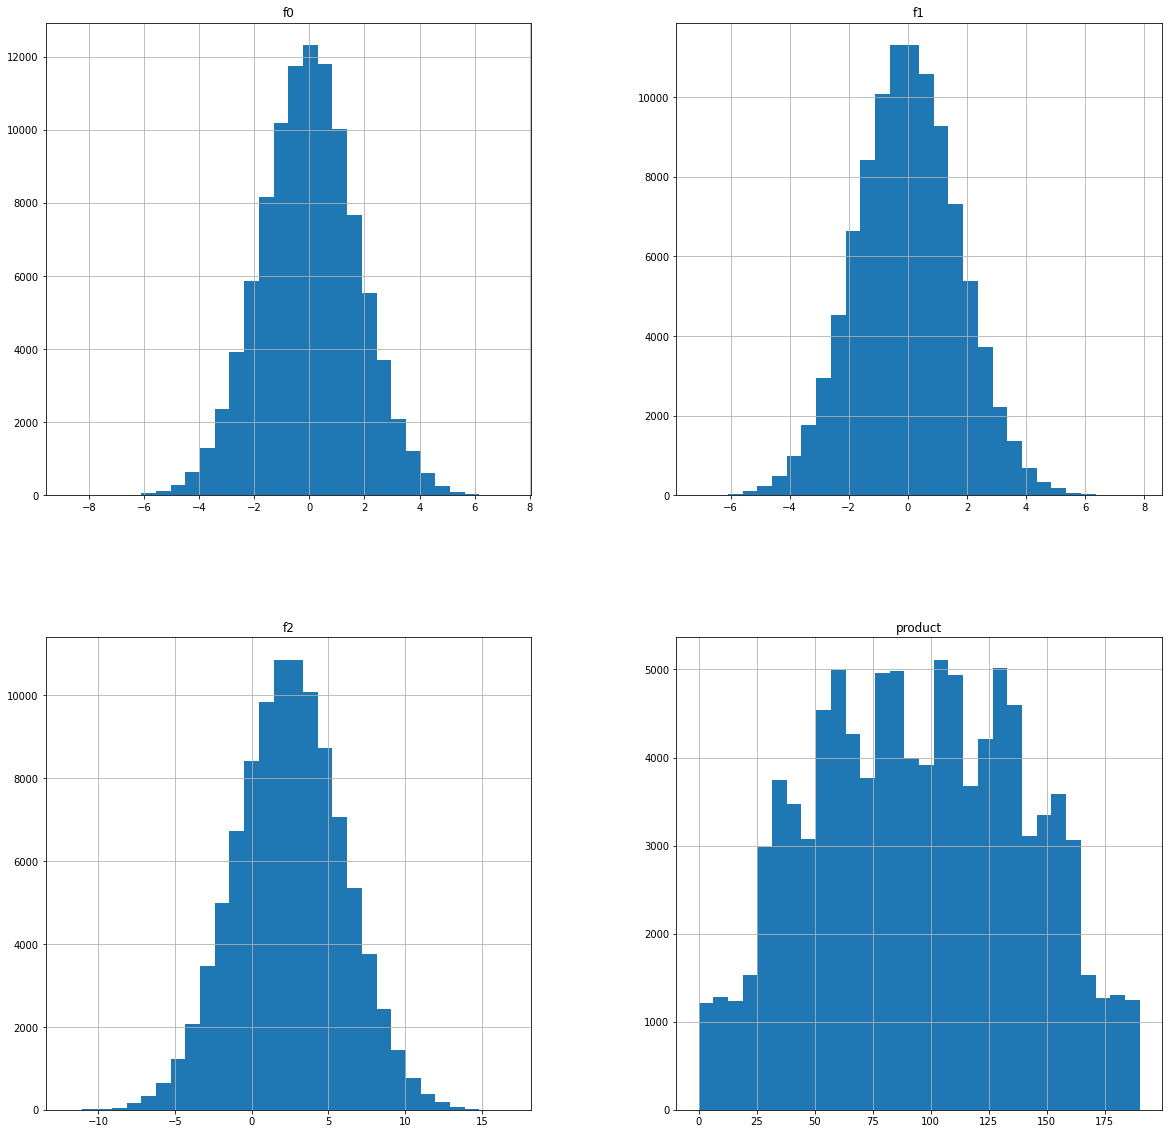

In [28]:
geo_data_2.drop('id', axis=1).hist(figsize=(20, 20),bins=30);

Выбросов не наблюдается.

Проанализируем количественные признаки.

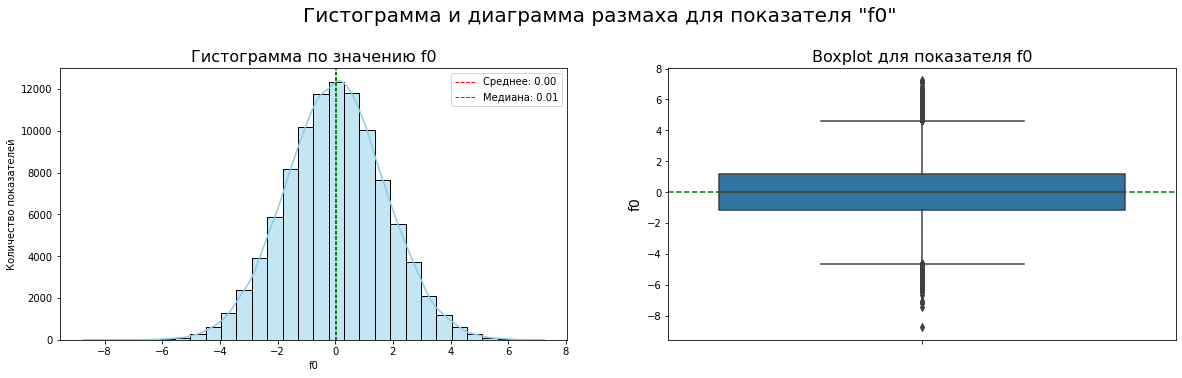

In [29]:
hist_plot(geo_data_2,'f0',30)

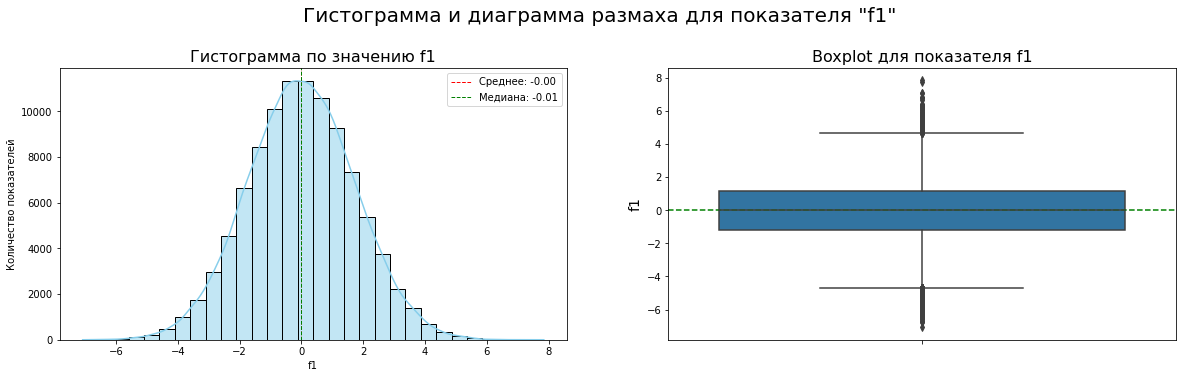

In [30]:
hist_plot(geo_data_2,'f1',30)

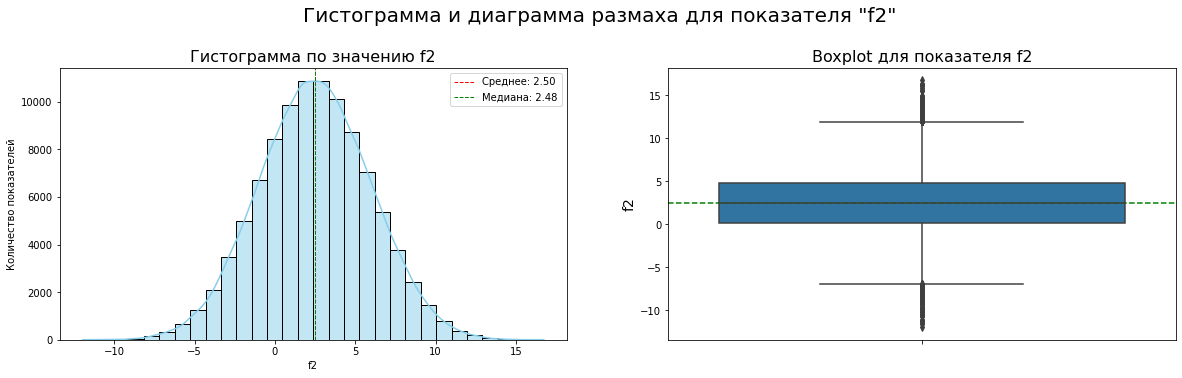

In [31]:
hist_plot(geo_data_2,'f2',30)

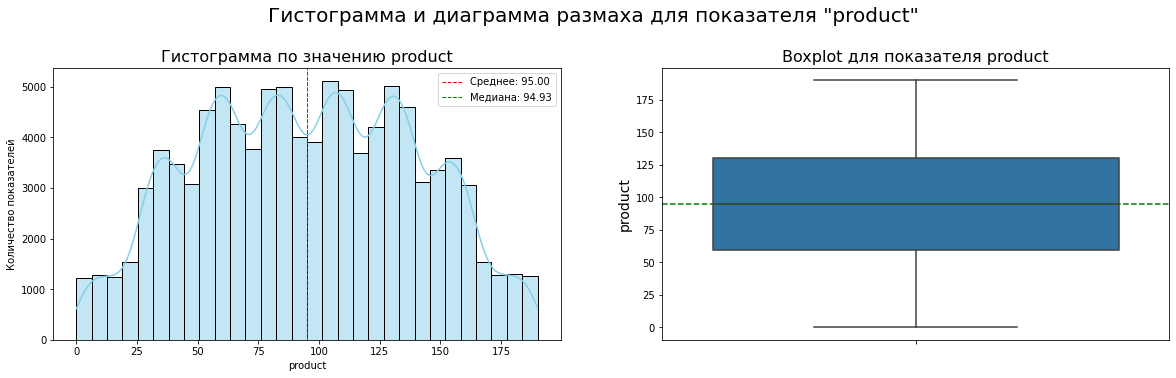

In [32]:
hist_plot(geo_data_2,'product',30)

Выведем сводную таблицу по медианным показателям признаков.

In [33]:
name = ['f0','f1','f2','product']
data = [geo_data_0,geo_data_1,geo_data_2]
geo  = pd.DataFrame(columns=name)
for i in data:
    list = []
    for col in name:
        median = round(np.median(i[col]),4)                  
        list.append(median)    
    geo = geo.append(pd.Series(list, index=name), ignore_index=True)
geo['geo'] = ['geo_data_0','geo_data_1','geo_data_2']
geo = geo.reindex(columns=['geo','f0','f1','f2','product'])
display(geo)

,geo,f0,f1,f2,product
0,geo_data_0,0.5024,0.2503,2.5160,91.8500
1,geo_data_1,1.1531,-4.8132,2.0115,57.0856
2,geo_data_2,0.0094,-0.0095,2.4842,94.9256


**<div style="border:solid green 2px; padding: 20px">
Вывод: На втором этапе был проведен исследовательский анализ данных. Были изучены распределения данных в признаках. Выбросы не обнаружены. Понятно, что характер признаков неизвестен, но по медианным значениям признаков f0 и f1 датасеты расходятся, по признаку f2 - относительно сопоставимы. По медианным объемам запасов geo_data_0 и geo_data_2 сопоставимы и почти в 2 раза больше того же показателя geo_data_1**

## Корреляционный анализ

### Корреляционный анализ для датасета 'geo_data_0'

Ниже представлена таблица коэффициентов корреляции (шкала Чеддока):

| Значение       | Интерпретация  |
|:--------------:|:--------------:|
| от 0 до 0,3    | очень слабая   |
| от 0,3 до 0,5  | слабая         |
| от 0, 5 до 0,7 | средняя        |
| от 0,7 до 0,9 | высокая        |
| от 0,9 до 1    | очень высокая  |

Используем библиотеку phik для подсчёта корреляции между признаками разных типов данных.

In [34]:
# создаём список с наименованиями количественных признаков
interval_cols = geo_data_0.select_dtypes(include=['float64']).columns.tolist()
    
def corr(data,title):
    # считаем корреляции
    phik_overview = phik_matrix(data.drop('id', axis=1), interval_cols=interval_cols)
    
    plot_correlation_matrix(
        phik_overview.values,
        x_labels=phik_overview.columns,
        y_labels=phik_overview.index,
        vmin=0, vmax=1, color_map='Greens',
        title=title,
        fontsize_factor=1.0,
        figsize=(5, 5)
    ) 

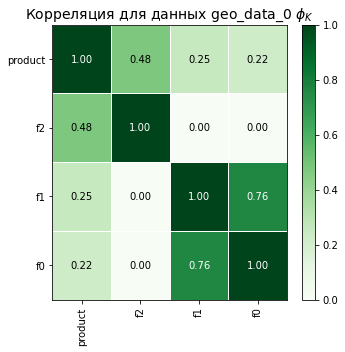

In [35]:
corr(geo_data_0,r'Корреляция для данных geo_data_0 $\phi_K$')

Наблюдается высокая корреляция между признаками f1 и f0. Мультиколлиниарности не наблюдается.

Построим диаграммы рассеяния scatterplot для признака 'product' и всех количественных признаков.

In [36]:
def diag_chart(data, data_name):
    fig,axes = plt.subplots(1, 3, figsize=(13, 3))
    plt.suptitle('Зависимость показателя product от признаков для '+data_name, fontsize=15, y=1.05)
    name = ['f0','f1','f2']
    for i,col in enumerate(name):
        sns.scatterplot(data=data, x=col, y='product',ax=axes[i])
    plt.show()

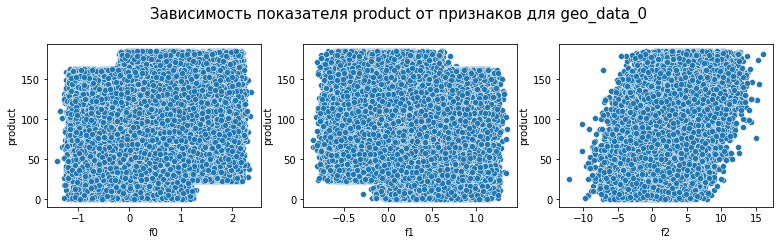

In [37]:
diag_chart(geo_data_0,'geo_data_0')

### Корреляционный анализ для датасета 'geo_data_1'

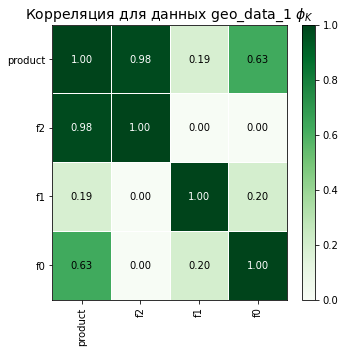

In [38]:
corr(geo_data_1,r'Корреляция для данных geo_data_1 $\phi_K$')

Наблюдается мультиколлинеарность между показателями product и f2 и средняя корреляция между f0 и product.

Построим диаграммы рассеяния scatterplot для признака 'product' и всех количественных признаков.

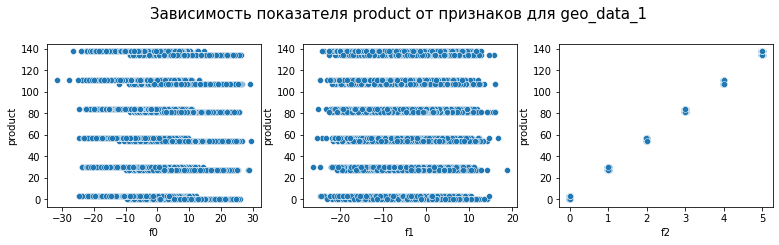

In [39]:
diag_chart(geo_data_1,'geo_data_1')

### Корреляционный анализ для датасета 'geo_data_2'

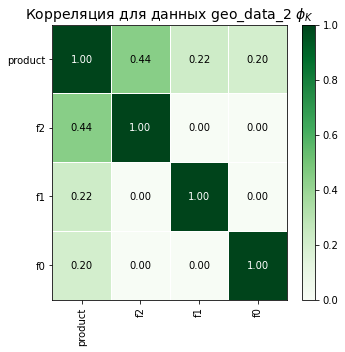

In [40]:
corr(geo_data_2,r'Корреляция для данных geo_data_2 $\phi_K$')

Наблюдается только слабая корреляция.

Построим диаграммы рассеяния scatterplot для признака 'product' и всех количественных признаков.

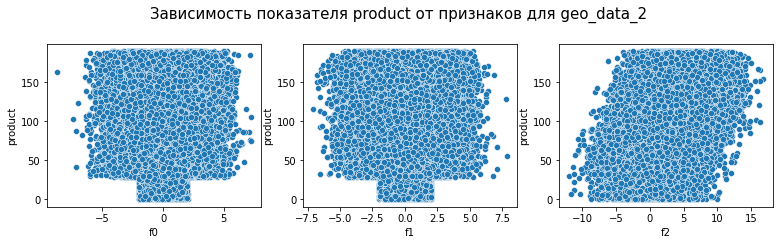

In [41]:
diag_chart(geo_data_2,'geo_data_2')

**<div style="border:solid green 2px; padding: 20px">
Вывод: На третьем этапе был проведен корреляционный анализ данных. Для geo_data_0 и geo_data_2 мультиколлинеарности не наблюдается. Но мультиколлинеарность наблюдается в geo_data_1. Но причины этого не известны, а признаков слишком мало, чтобы выкидывать признак f2. Хотя мы понимаем, что это серьезно повлияет на обучение модели.**

## Обучение и проверка модели

### Обучение и проверка модели для 'geo_data_0'

In [42]:
drop_list = ['id','product']
def model(data):
    global product_pred
    X = data.drop(drop_list, axis=1)
    y = data['product']
    # Разбивка данных на обучающую и валидационную выборки
    X_train, X_test, y_train, y_test = train_test_split(
            X, 
            y,
            test_size=0.25,
            random_state=RANDOM_STATE)

    # Обучение модели и предсказания на валидационной выборке

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # инициализирование модели линейной регрессии
    model_lr  = LinearRegression()

    # обучение модели на тренировочных данных
    model_lr.fit(X_train_scaled, y_train)

    # получение предсказания модели на валидационных данных 
    # сохранение результата в переменную predictions
    predictions = model_lr.predict(X_test_scaled)

    r2 = r2_score(y_test, predictions)
    
    # вывод полученного значения R2
    print("R2 LinearRegression =", r2)

    # проведение анализа остатков
    residuals = y_test - predictions

    # построение графиков по количественным признакам — гистограмму частотности 
    # распределения и диаграмму рассеяния
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,7))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    axes[0].hist(residuals, bins = 30)
    axes[0].set_title('Гистограмма распределения остатков')
    axes[0].set_xlabel('Остатки')

    axes[1].scatter(predictions,residuals)
    axes[1].set_xlabel('Предсказания модели')
    axes[1].set_ylabel('Остатки')
    axes[1].set_title('Анализ дисперсии')
    plt.show()
    
    #сохраняем предсказания и правильные ответы на вилидационной выборке
    pred_data = pd.DataFrame(predictions, columns=['pred_product'])
    product_pred = pd.concat([X_test.reset_index(drop=True),
                              y_test.reset_index(drop=True),
                              pred_data.reset_index(drop=True)], axis=1)
    display(product_pred)
    
    # напечатаем на экране средний запас предсказанного сырья
    print('Средний запас предсказанного сырья:',round(predictions.mean(),3),'тыс. баррелей')
    # получение значения RMSE
    rmse = math.sqrt(mean_squared_error(predictions, y_test))
    print('RMSE = ',round(rmse,3))

R2 LinearRegression = 0.2728287328173471


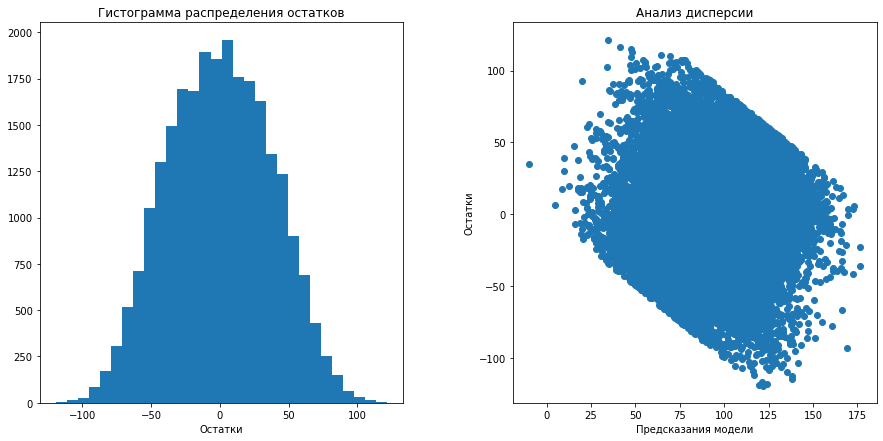

,f0,f1,f2,product,pred_product
0,0.599283,-0.557623,2.121187,122.073350,101.901017
1,0.739017,-0.463156,-1.347584,48.738540,78.217774
2,1.422743,-0.534917,3.718798,131.338088,115.266901
3,1.580244,-0.238458,2.805149,88.327757,105.618618
4,0.918974,0.023961,2.598575,36.959266,97.980185
...,...,...,...,...,...
24995,0.754647,-0.512213,2.610771,148.821520,105.076959
24996,-0.062056,0.516884,0.714446,123.454003,74.768176
24997,0.593769,-0.425260,-0.525017,91.945213,82.544397
24998,0.198209,0.453940,1.497557,149.295563,81.826689


Средний запас предсказанного сырья: 92.399 тыс. баррелей
RMSE =  37.757


In [43]:
model(geo_data_0)
geo_data_0_table = product_pred.copy()

Значение R2 слишком мало. Гистограмма имеет сдвиг вправо, а чередование маленьких и больших дисперсий остатков не выражено.

### Обучение и проверка модели для 'geo_data_1'

R2 LinearRegression = 0.9996245232002449


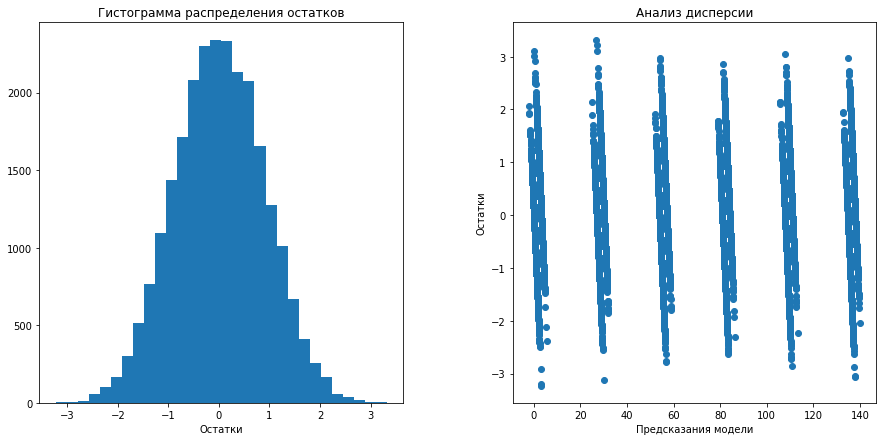

,f0,f1,f2,product,pred_product
0,6.078076,0.084568,0.002957,0.000000,0.844738
1,16.462386,2.712946,1.993030,53.906522,52.921612
2,7.051898,0.766983,4.990194,134.766305,135.110385
3,-0.240045,-0.380804,3.999693,107.813044,109.494863
4,13.350111,-8.558281,0.002010,0.000000,-0.047292
...,...,...,...,...,...
24995,8.141417,-0.832158,4.001976,107.813044,108.351600
24996,16.601751,-8.141232,2.010371,53.906522,53.604049
24997,14.674777,-5.633890,1.004171,26.953261,26.708734
24998,-1.381118,-5.464254,4.001648,110.992147,109.823087


Средний запас предсказанного сырья: 68.713 тыс. баррелей
RMSE =  0.89


In [44]:
model(geo_data_1)
geo_data_1_table = product_pred.copy()

Значение R2 хорошее. Гистограмма не имеет сдвигов, но наблюдается чередование маленьких и больших дисперсий остатков.

### Обучение и проверка модели для 'geo_data_2'

R2 LinearRegression = 0.19634705977280487


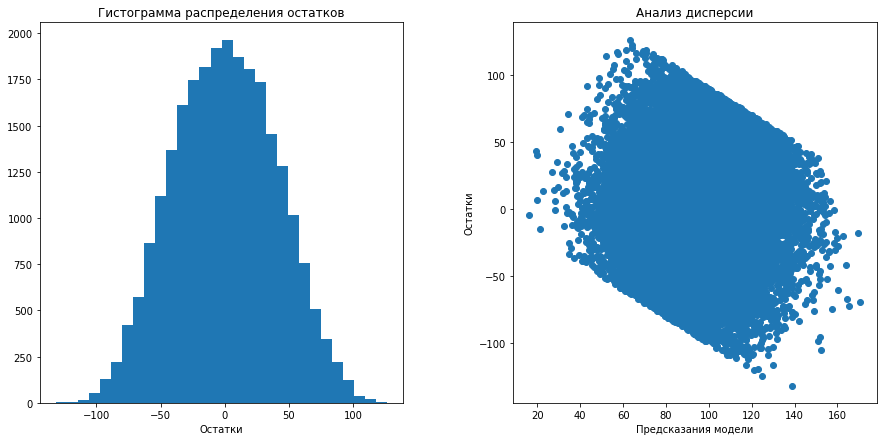

,f0,f1,f2,product,pred_product
0,2.111118,-1.679773,3.112240,117.441301,98.301916
1,0.734759,0.747788,3.670879,47.841249,101.592461
2,-2.513109,0.844631,-4.922889,45.883483,52.449099
3,-2.035301,-1.522988,5.072839,139.014608,109.922127
4,2.744145,1.429952,-1.372661,84.004276,72.411847
...,...,...,...,...,...
24995,-1.532677,0.365315,3.840436,40.797226,102.764169
24996,1.381244,1.168552,2.262261,87.144239,93.431823
24997,2.902487,0.839203,-2.817721,52.039812,64.098390
24998,0.942093,-1.424641,0.567559,136.961454,83.764135


Средний запас предсказанного сырья: 94.771 тыс. баррелей
RMSE =  40.146


In [45]:
model(geo_data_2)
geo_data_2_table = product_pred.copy()

Значение R2 слишком мало. Гистограмма не имеет сдвигов, а чередование маленьких и больших дисперсий остатков не выражено.

**<div style="border:solid green 2px; padding: 20px">
Вывод: На четвертом этапе были обучены 3 модели LinearRegression. Для geo_data_0 и geo_data_2 значение R2 низкое, а значения RMSE слишком высокое, учитывая средние показатели запасов предсказанного сырья. Для geo_data_1 наблюдается обратная картина, но причина, вероятнее всего, кроется в наличии мультиколлинеарности.**

## Подготовка к расчету прибыли

### Сохранение всех ключевых значений для расчётов в отдельных переменных

In [46]:
ALL_POINTS = 500
BEST_POINTS = 200
BUDGET = 10000000000
PRICE_1_BAR = 450
price_1000_bar = PRICE_1_BAR*1000

### Расчет достаточного объёма сырья для безубыточной разработки новой скважины

In [47]:
bar = BUDGET/(BEST_POINTS*price_1000_bar)
print('Достаточный объем сырья для безубыточной разработки новой скважины:',
      round(bar,2),'тыс. баррелей')

Достаточный объем сырья для безубыточной разработки новой скважины: 111.11 тыс. баррелей


### Сравнение полученного объёма сырья со средним запасом в каждом регионе

In [48]:
data = [geo_data_0,geo_data_1,geo_data_2]
name = ['Среднее','Достаточный объем','Разница']
data_bar = pd.DataFrame()
for i in data:
    list = []
    mean = round(np.mean(i['product']),2)
    list.append(mean)
    list.append(round(bar,2))
    list.append(round(mean-bar,2))
    data_bar = data_bar.append(pd.Series(list, index=name), ignore_index=True)
data_bar['geo'] = ['geo_data_0','geo_data_1','geo_data_2']
data_bar = data_bar.reindex(columns=['geo','Среднее','Достаточный объем','Разница'])
display(data_bar)   

,geo,Среднее,Достаточный объем,Разница
0,geo_data_0,92.50,111.11,-18.61
1,geo_data_1,68.83,111.11,-42.28
2,geo_data_2,95.00,111.11,-16.11


**<div style="border:solid green 2px; padding: 20px">
Вывод: На пятом этапе был получен необходимый объем запаса сырья для безубыточной разработки новой скважины. По результатам сравнения ни один регион не имеет необходимого запаса.**

## Вывод функции для расчёта прибыли по выбранным скважинам и предсказаниям модели

### Отбор скважин для 'geo_data_0', суммирование целевого значения сырья и расчет прибыли

In [49]:
def func_200(test,pred):
    global sum_product, sum_profit
    pred_sort = pred.sort_values(ascending=False)
    points_200 = test[pred_sort.index][:BEST_POINTS]
    sum_product = points_200.sum()
    sum_profit = sum_product*price_1000_bar-BUDGET
    return sum_profit
func_200(geo_data_0_table['product'],geo_data_0_table['pred_product'])    
print('Сумма целевого значения сырья, соответствующее предсказаниям:',
            round(sum_product,2),'тыс. баррелей')
print('Прибыль от ',round(sum_product,2),' тыс. баррелей:',round(sum_profit,2),'руб.')

Сумма целевого значения сырья, соответствующее предсказаниям: 29686.98 тыс. баррелей
Прибыль от  29686.98  тыс. баррелей: 3359141114.46 руб.


### Отбор скважин для 'geo_data_1', суммирование целевого значения сырья и расчет прибыли

In [50]:
func_200(geo_data_1_table['product'],geo_data_1_table['pred_product'])    
print('Сумма целевого значения сырья, соответствующее предсказаниям:',
            round(sum_product,2),'тыс. баррелей')
print('Прибыль от ',round(sum_product,2),' тыс. баррелей:',round(sum_profit,2),'руб.')

Сумма целевого значения сырья, соответствующее предсказаниям: 27589.08 тыс. баррелей
Прибыль от  27589.08  тыс. баррелей: 2415086696.68 руб.


### Отбор скважин для 'geo_data_2', суммирование целевого значения сырья и расчет прибыли

In [51]:
func_200(geo_data_2_table['product'],geo_data_2_table['pred_product'])    
print('Сумма целевого значения сырья, соответствующее предсказаниям:',
            round(sum_product,2),'тыс. баррелей')
print('Прибыль от ',round(sum_product,2),' тыс. баррелей:',round(sum_profit,2),'руб.')

Сумма целевого значения сырья, соответствующее предсказаниям: 27996.83 тыс. баррелей
Прибыль от  27996.83  тыс. баррелей: 2598571759.37 руб.


**<div style="border:solid green 2px; padding: 20px">
Вывод: На шестом этапе по каждому региону были получены 200 точек с самыми большими запасами сырья, проведено суммирование целевого значения запаса сырья по полученным предсказаниям и рассчитана прибыль для получения объема сырья.**

## Расчет рисков и прибылей для каждого региона

**Риск убытков** - это вероятность внезапного неблагоприятного финансового положения, которое может привести к убыткам для компании.

### Расчет рисков и прибылей для 'geo_data_0'

In [52]:
def risk_95_mean(data,name):
    values = []
    for i in range(1000):
        test_subsample = data['product'].sample(n=ALL_POINTS, replace=True, random_state=state)
        selected_pred = data['pred_product'][test_subsample.index]
        profit = func_200(test_subsample,selected_pred)
        values.append(profit)
    values = pd.Series(values)
    lower = values.quantile(q=0.025)
    upper = values.quantile(q=0.0975)
    risk = round(values.apply(lambda x: x < 0).sum()/len(values)*100,3)
    print('Средняя прибыль для ',name,':',round(values.mean(),2),'рублей')
    print('95%-й доверительный интервал для ',name,':',round(lower,2),'-',round(upper,2),'рублей')
    print('Риск убытков для ',name,':',risk,'%')

In [53]:
risk_95_mean(geo_data_0_table,'geo_data_0')

Средняя прибыль для  geo_data_0 : 435933772.14 рублей
95%-й доверительный интервал для  geo_data_0 : -116231612.78 - 63816857.77 рублей
Риск убытков для  geo_data_0 : 6.1 %


### Расчет рисков и прибылей для 'geo_data_1'

In [54]:
risk_95_mean(geo_data_1_table,'geo_data_1')

Средняя прибыль для  geo_data_1 : 498569016.92 рублей
95%-й доверительный интервал для  geo_data_1 : 75315573.09 - 223433279.77 рублей
Риск убытков для  geo_data_1 : 1.0 %


### Расчет рисков и прибылей для 'geo_data_2'

In [55]:
risk_95_mean(geo_data_2_table,'geo_data_2')

Средняя прибыль для  geo_data_2 : 412672898.99 рублей
95%-й доверительный интервал для  geo_data_2 : -158939515.76 - 40041245.53 рублей
Риск убытков для  geo_data_2 : 7.0 %


<div style="border:solid green 2px; padding: 20px">
Вывод: На седьмом этапе была применена техника Bootstrap с 1000 выборок, чтобы найти распределение прибыли для каждого региона. Также для каждого региона была найдена средняя прибыль, 95% доверительный интервал и величина риска убытков. Наилучшие показатели показал второй регион (geo_data_1) по следующим причинам:
    
- наибольшая средняя прибыль
- 95% доверительный интервал лежит в границах положительных значений (соответственно, уже можно делать вывод, что отрицательные значения прибыли будут выбросами с учетом заявленных условий)
- риск убытков самый маленький по регионам.

## Итоговый вывод

<div style="border:solid green 2px; padding: 20px">

По результатам проекта были выполнены следующие этапы:
    
- Загрузка и предобработка данных
- Исследовательский анализ данных
- Корреляционный анализ
- Обучение и проверка модели для каждого региона
- Подготовка к расчёту прибыли
- Вывод функции для расчёта прибыли по выбранным скважинам и предсказаниям модели:
- Расчет рисков и прибыли для каждого региона

По итогам работы предполагается, что регион №2 (по датасету geo_data_1) будет наилушим регионом для проведения разработки скважин, т.к.:
- наблюдается наибольшая средняя прибыль
- 95% доверительный интервал лежит в границах положительных значений (соответственно, уже можно делать вывод, что отрицательные значения прибыли будут выбросами с учетом заявленных условий)
- риск убытков самый маленький по регионам